    Testing signature projection assessment functions :

In [1]:
import py.py_models as pyM
import py.py_plots as pyP
import py.py_util as pyU
import pandas as pd
import numpy as np


In [23]:
bulk_vst = pd.read_csv("/mnt/d/PREDIMEL/00_Merged_data/02_BULK/02_Filtered_min15_in0.33_nocont/RNAseq_vst.csv", index_col=0)
clinic_annot = pd.read_csv("/mnt/d/PREDIMEL/00_Merged_data/01_CLINIC/clinic_merged_cellularity.csv", index_col=1)

IFNg_signature = ["IDO1", "CXCL10", "CXCL9", "HLA-DRA", "STAT1", "IFNG"]
IFNg_expanded_signature = ["CD3D", "IDO1", "CIITA", "CD3E", "CCL5", "GZMK", "CD2", "HLA-DRA", "CXCL13", "IL2RG", "NKG7", "HLA-E", "CXCR6", "LAG3", "TAGAP", "CXCL10", "STAT1", "GZMB"]
T_cell_inflammed = ["PSMB10","HLA-DRA","CMKLR1","HLA-E","CXCL9","CXCL10","IDO1","CXCR6","CD27","CCL5","NKG7","STAT1","GZMB","HLA-B","CD8A","PRF1","LAG3","CD276"]

IFNg_subset = bulk_vst.loc[T_cell_inflammed, :]
IFNg_score_mean = IFNg_subset.mean(axis=0)
df_IFNg_score = pd.DataFrame({"score" : IFNg_score_mean.values}, index= IFNg_score_mean.index)


df_IFNg_score, clinic_annot = pyU.align_on_index(df_IFNg_score, clinic_annot)
responders = clinic_annot.iloc[(clinic_annot.loc[:,"PDSD_vs_PRCR_meil12m"] == "R").values, :]
non_responders = clinic_annot.iloc[(clinic_annot.loc[:,"PDSD_vs_PRCR_meil12m"] == "NR").values, :]

non_responders = non_responders.index
responders = responders.index


57 IDs communs conservés (ordre synchronisé).


Using N=57 patients (responders=31, non-responders=26)


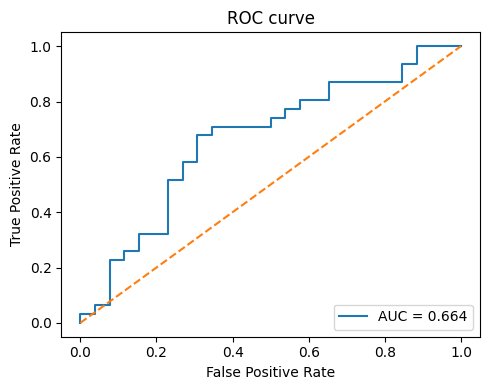

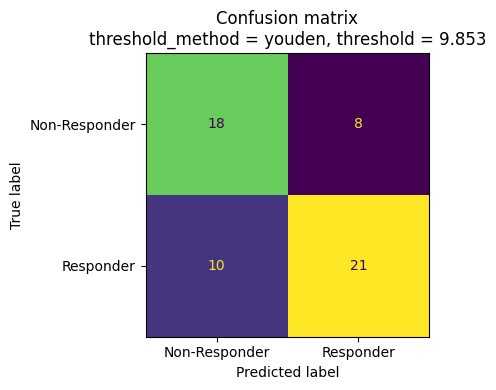

ROC-AUC = 0.6638
Selected threshold method = youden
Selected threshold = 9.852621
Confusion matrix:
[[18  8]
 [10 21]]
ACC=0.6842 | PREC=0.7241 | REC=0.6774 | F1=0.7000


{'ids': ['001-0107',
  '001-0006',
  '001-0028',
  '001-0090',
  '001-0108',
  '001-0101',
  '001-0102',
  '001-0056',
  '001-0038',
  '001-0064',
  '001-0103',
  '001-0023',
  '001-0112',
  '001-0027',
  '001-0034',
  '001-0002',
  '001-0075',
  '001-0037',
  '001-0081',
  '001-0072',
  '001-0058',
  '001-0067',
  '001-0104',
  '001-0003',
  '001-0087',
  '001-0052',
  '001-0069',
  '001-0062',
  '001-0096',
  '001-0001',
  '001-0012',
  '001-0063',
  '001-0098',
  '001-0036',
  '001-0010',
  '001-0019',
  '001-0032',
  '001-0046',
  '001-0024',
  '001-0084',
  '001-0020',
  '001-0049',
  '001-0008',
  '001-0030',
  '001-0057',
  '001-0111',
  '001-0043',
  '001-0079',
  '001-0025',
  '001-0022',
  '001-0021',
  '001-0029',
  '001-0055',
  '001-0080',
  '001-0083',
  '001-0089',
  '001-0014'],
 'y_true': array([1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        0, 1, 1, 0, 0, 0, 1, 1, 0, 0

In [24]:

pyP.myROC_AUC_v2(df_IFNg_score, responders, non_responders)


In [7]:
import json
with open("/home/quentin/01_PROJETS/43_Shiny_bis/REF_DATA/genesets_and_pathways/c2_all_genesets.json") as f:
    genesets = json.load(f)


In [ ]:
genesets

7561